In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# Input nilai suhu dalam satuan celcius
# Input waktu dalam satuan menit

To = float(input('Suhu awal sistem (To): '))
Tx = float(input('Suhu saat waktu tx: (Tx): '))
Tenv = float(input('Suhu lingkungan (Tenv): '))
to = int(input('Waktu awal (to): '))
tx = int(input('Waktu pengukuran Tx (tx): '))

In [3]:
# konstanta pendinginan
alpha = -1/(tx - to) * np.log((Tx - Tenv)/(To - Tenv))

# Fungsi persamaan dan konversi 
def newtons_cooling_law(t, alpha):
    return Tenv + (To - Tenv) * np.exp(-alpha*(t - to))

def to_fahrenheit(c):
    return (c * 9/5) + 32

def to_kelvin(c):
    return c + 273.15

In [4]:
time_input = input('Masukkan waktu dalam menit (Pisah dengan koma): ')
dTime = [float(t) for t in time_input.split(',')]

dTemp_C = [newtons_cooling_law(t, alpha) for t in dTime]
dTemp_F = [to_fahrenheit(c) for c in dTemp_C]
dTemp_K = [to_kelvin(c) for c in dTemp_C]

In [5]:
end_time = max(max(dTime), tx) + 10
time_range = np.arange(to, end_time + 1, 1)

temp_C = newtons_cooling_law(time_range, alpha)
temp_F = [to_fahrenheit(c) for c in temp_C]
temp_K = [to_kelvin(c) for c in temp_C]

In [6]:
print('Hasil laju perubahan suhu terhadap waktu:\n')
for t, c, f, k in zip(dTime, dTemp_C, dTemp_F, dTemp_K):
    print(f'Waktu: {t} menit -> {c:.2f}°C | {f:.2f}°F | {k:.2f}K')

Hasil laju perubahan suhu terhadap waktu:

Waktu: 20.0 menit -> 53.93°C | 129.07°F | 327.08K
Waktu: 30.0 menit -> 43.60°C | 110.47°F | 316.75K
Waktu: 40.0 menit -> 36.96°C | 98.52°F | 310.11K
Waktu: 50.0 menit -> 32.69°C | 90.83°F | 305.84K
Waktu: 60.0 menit -> 29.94°C | 85.89°F | 303.09K


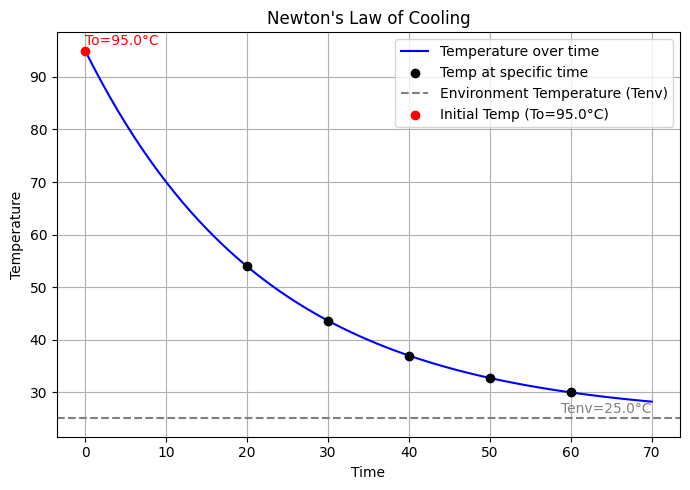

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(time_range, temp_C, label='Temperature over time', color='blue')
plt.scatter(dTime, dTemp_C, color='black', label='Temp at specific time', zorder=5)

plt.axhline(y=Tenv, color='gray', linestyle='--', label='Environment Temperature (Tenv)')
plt.text(time_range[-1], Tenv + 1, f'Tenv={Tenv}°C', color='gray', ha='right')

plt.scatter([to], [To], color='red', zorder=6, label=f'Initial Temp (To={To}°C)')
plt.text(to, To + 1, f'To={To}°C', color='red')

plt.title("Newton's Law of Cooling")
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()